# Visualizations

Now that we have determined our feature importances, we'll explore our data visually.

### Common Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl

In [2]:
# suppress warnings
import warnings

warnings.filterwarnings("ignore")

### 1. Load Data

In [3]:
df = pkl.load(open("../../../data/interim/vbac/X_train.pkl", "rb"))
successful_vbac = pkl.load(open("../../../data/processed/vbac/y_train.pkl", "rb"))
feature_importances_df = pkl.load(
    open("../../../data/processed/vbac/feature_importances_df.pkl", "rb")
)

In [4]:
head = df.head()

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 443145 entries, 1779560 to 569093
Columns: 105 entries, birth_month to no_congenital_abnormalities_reported
dtypes: float64(35), int64(70)
memory usage: 358.4 MB


In [6]:
top_features = feature_importances_df[feature_importances_df["importance"] > 0.01]

top_features

,feature,importance
1505,Categorical Pipeline__augmentation_of_labor_1.0,0.069416
1504,Categorical Pipeline__induction_of_labor_1.0,0.051625
1516,Categorical Pipeline__attendant_at_birth_3.0,0.050293
1585,Numerical Pipeline__time_of_birth,0.047317
1588,Numerical Pipeline__prior_births_now_living,0.023729
1600,Numerical Pipeline__number_of_previous_cesarean,0.021690
1514,Categorical Pipeline__trial_of_labor_attempted...,0.018494
1598,Numerical Pipeline__BMI,0.018152
1602,Numerical Pipeline__birth_weight_in_grams,0.017497
1550,Categorical Pipeline__obstetric_estimate_recod...,0.015310


We have 17 features with an importance > 1%, so we'll focus on visualizing those primarily.

### 2. Univariate Visualization

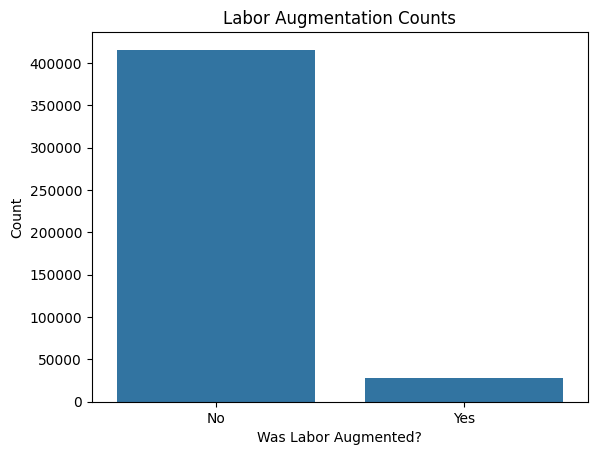

In [7]:
augmentation_of_labor_value_counts = df["augmentation_of_labor"].value_counts()

labor_augmentation_bar_ax = sns.barplot(
    x=augmentation_of_labor_value_counts.index,
    y=augmentation_of_labor_value_counts.values,
)
labor_augmentation_bar_ax.set_title("Labor Augmentation Counts")
labor_augmentation_bar_ax.set_xlabel("Was Labor Augmented?")
labor_augmentation_bar_ax.set_xticklabels(["No", "Yes"])
labor_augmentation_bar_ax.set_ylabel("Count")
plt.show()

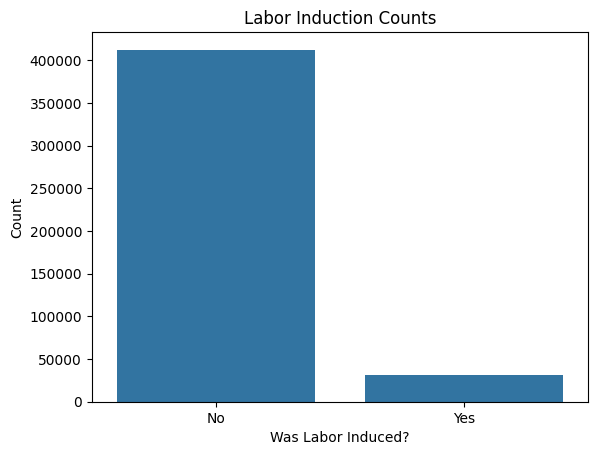

In [8]:
induction_of_labor_value_counts = df["induction_of_labor"].value_counts()

induction_of_labor_bar_ax = sns.barplot(
    x=induction_of_labor_value_counts.index,
    y=induction_of_labor_value_counts.values,
)
induction_of_labor_bar_ax.set_title("Labor Induction Counts")
induction_of_labor_bar_ax.set_xlabel("Was Labor Induced?")
induction_of_labor_bar_ax.set_xticklabels(["No", "Yes"])
induction_of_labor_bar_ax.set_ylabel("Count")
plt.show()

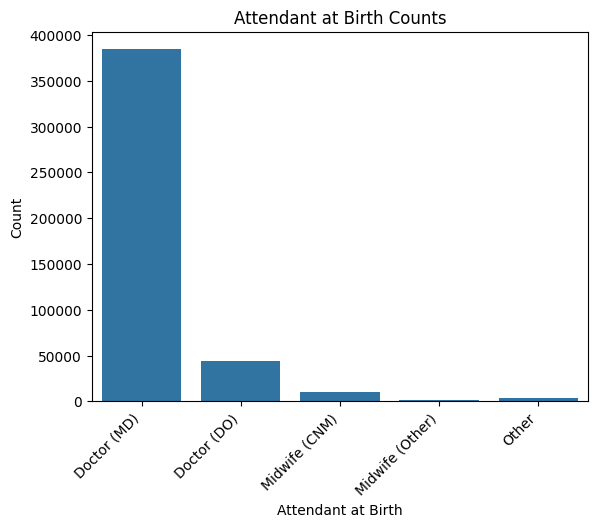

In [9]:
attendant_at_birth_value_counts = df["attendant_at_birth"].value_counts()
attendant_at_birth_value_counts = attendant_at_birth_value_counts.drop(9)

attendant_at_birth_bar_ax = sns.barplot(
    x=attendant_at_birth_value_counts.index,
    y=attendant_at_birth_value_counts.values,
)
attendant_at_birth_bar_ax.set_title("Attendant at Birth Counts")
attendant_at_birth_bar_ax.set_xlabel("Attendant at Birth")
attendant_at_birth_bar_ax.set_xticklabels(
    [
        "Doctor (MD)",
        "Doctor (DO)",
        "Midwife (CNM)",
        "Midwife (Other)",
        "Other",
    ],
    rotation=45,
    ha="right",
)

attendant_at_birth_bar_ax.set_ylabel("Count")
plt.show()

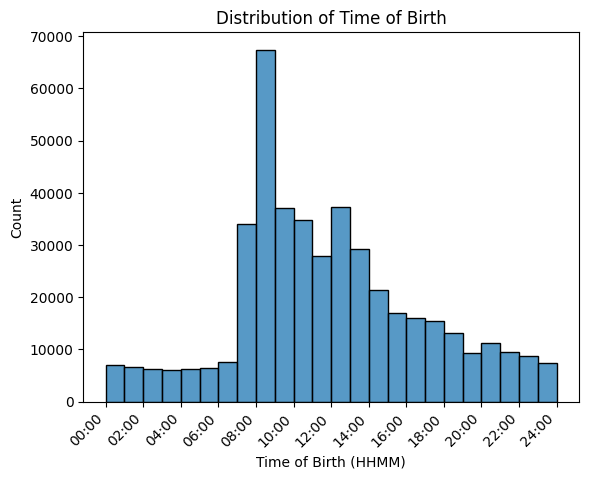

In [10]:
time_of_birth_value_counts = df["time_of_birth"].value_counts()
time_of_birth_value_counts = time_of_birth_value_counts.drop(9999)

time_of_birth_bar_ax = sns.histplot(
    x=time_of_birth_value_counts.index,
    weights=time_of_birth_value_counts.values,
    bins=range(0, 2401, 100),
)
time_of_birth_bar_ax.set_title("Distribution of Time of Birth")
time_of_birth_bar_ax.set_xlabel("Time of Birth (HHMM)")
time_of_birth_bar_ax.set_xticks(
    ticks=range(0, 2401, 200),
    labels=[f"{int(hour):02d}:00" for hour in range(0, 25, 2)],
    rotation=45,
    ha="right",
)
time_of_birth_bar_ax.set_ylabel("Count")
plt.show()

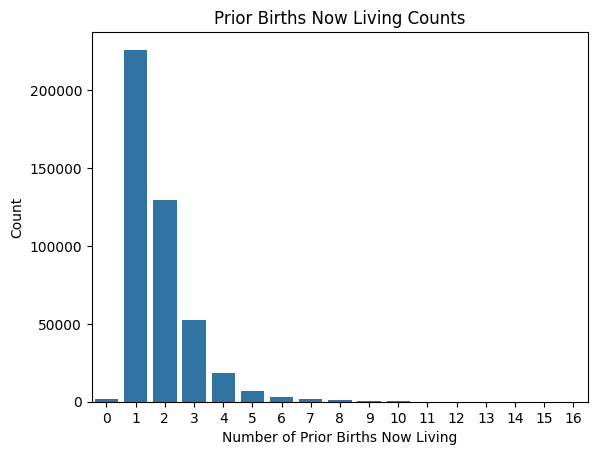

In [11]:
prior_births_now_living_value_counts = df["prior_births_now_living"].value_counts()
prior_births_now_living_value_counts = prior_births_now_living_value_counts.drop(99)

prior_births_now_living_bar_ax = sns.barplot(
    x=prior_births_now_living_value_counts.index,
    y=prior_births_now_living_value_counts.values,
)
prior_births_now_living_bar_ax.set_title("Prior Births Now Living Counts")
prior_births_now_living_bar_ax.set_xlabel("Number of Prior Births Now Living")
prior_births_now_living_bar_ax.set_ylabel("Count")
plt.show()

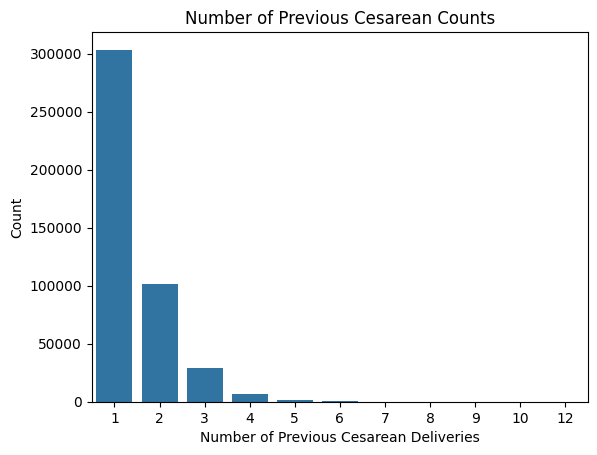

In [12]:
number_of_previous_cesarean_value_counts = df[
    "number_of_previous_cesarean"
].value_counts()
number_of_previous_cesarean_value_counts = (
    number_of_previous_cesarean_value_counts.drop(99)
)
number_of_previous_cesarean_bar_ax = sns.barplot(
    x=number_of_previous_cesarean_value_counts.index,
    y=number_of_previous_cesarean_value_counts.values,
)
number_of_previous_cesarean_bar_ax.set_title("Number of Previous Cesarean Counts")
number_of_previous_cesarean_bar_ax.set_xlabel("Number of Previous Cesarean Deliveries")
number_of_previous_cesarean_bar_ax.set_ylabel("Count")
plt.show()

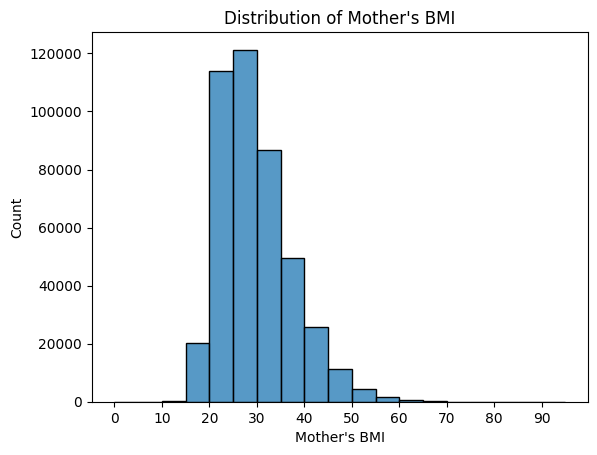

In [13]:
BMI_value_counts = df["BMI"].value_counts()

BMI_bar_ax = sns.histplot(
    x=BMI_value_counts.index, weights=BMI_value_counts.values, bins=range(0, 100, 5)
)
BMI_bar_ax.set_title("Distribution of Mother's BMI")
BMI_bar_ax.set_xlabel("Mother's BMI")
BMI_bar_ax.set_xticks(ticks=range(0, 100, 10))
BMI_bar_ax.set_ylabel("Count")
plt.show()

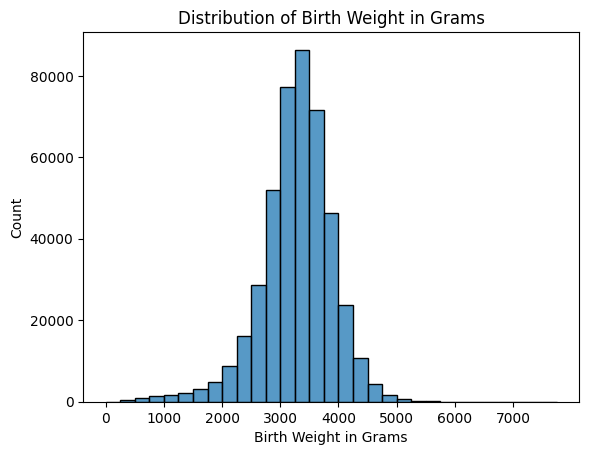

In [14]:
birth_weight_in_grams_value_counts = df["birth_weight_in_grams"].value_counts()
birth_weight_in_grams_value_counts = birth_weight_in_grams_value_counts.drop(9999)

birth_weight_in_grams_bar_ax = sns.histplot(
    x=birth_weight_in_grams_value_counts.index,
    weights=birth_weight_in_grams_value_counts.values,
    bins=range(0, 8000, 250),
)
birth_weight_in_grams_bar_ax.set_title("Distribution of Birth Weight in Grams")
birth_weight_in_grams_bar_ax.set_xlabel("Birth Weight in Grams")
birth_weight_in_grams_bar_ax.set_xticks(ticks=range(0, 8000, 1000))
birth_weight_in_grams_bar_ax.set_ylabel("Count")
plt.show()

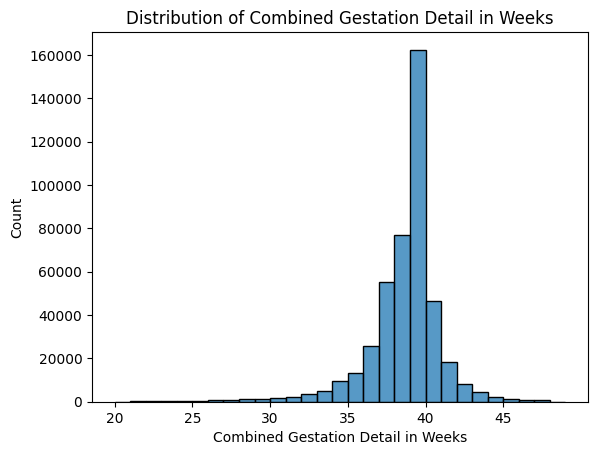

In [15]:
# rather than use the gestation estimate recode, we'll use the combined gestation detail in weeks, which is more granular

combined_gestation_detail_value_counts = df[
    "combined_gestation_detail_in_weeks"
].value_counts()
combined_gestation_detail_value_counts = combined_gestation_detail_value_counts.drop(99)

combined_gestation_detail_bar_ax = sns.histplot(
    x=combined_gestation_detail_value_counts.index,
    weights=combined_gestation_detail_value_counts.values,
    bins=range(20, 50, 1),
)
combined_gestation_detail_bar_ax.set_title(
    "Distribution of Combined Gestation Detail in Weeks"
)
combined_gestation_detail_bar_ax.set_xlabel("Combined Gestation Detail in Weeks")
combined_gestation_detail_bar_ax.set_xticks(ticks=range(20, 50, 5))
combined_gestation_detail_bar_ax.set_ylabel("Count")
plt.show()

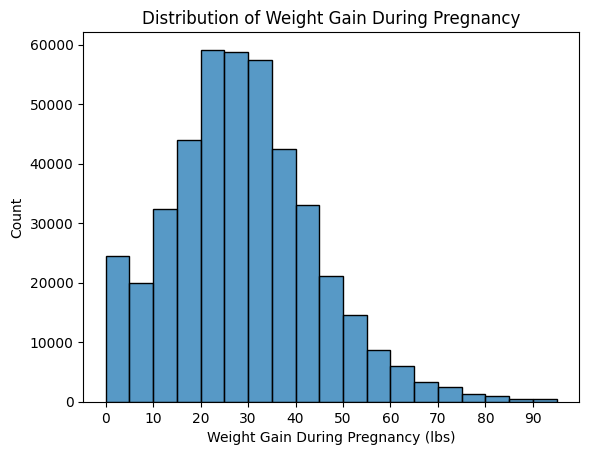

In [16]:
weight_gain_value_counts = df["weight_gain"].value_counts()

weight_gain_bar_ax = sns.histplot(
    x=weight_gain_value_counts.index,
    weights=weight_gain_value_counts.values,
    bins=range(0, 100, 5),
)
weight_gain_bar_ax.set_title("Distribution of Weight Gain During Pregnancy")
weight_gain_bar_ax.set_xlabel("Weight Gain During Pregnancy (lbs)")
weight_gain_bar_ax.set_xticks(ticks=range(0, 100, 10))
weight_gain_bar_ax.set_ylabel("Count")
plt.show()

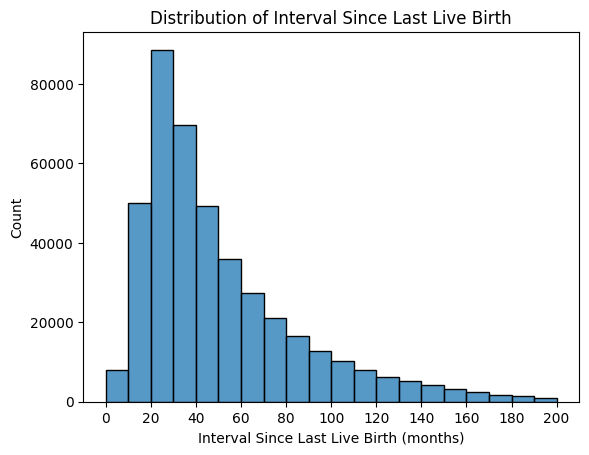

In [17]:
interval_since_last_live_birth_value_counts = df[
    "interval_since_last_live_birth"
].value_counts()
interval_since_last_live_birth_value_counts = (
    interval_since_last_live_birth_value_counts.drop(999)
)

interval_since_last_live_birth_bar_ax = sns.histplot(
    x=interval_since_last_live_birth_value_counts.index,
    weights=interval_since_last_live_birth_value_counts.values,
    bins=range(0, 201, 10),
)
interval_since_last_live_birth_bar_ax.set_title(
    "Distribution of Interval Since Last Live Birth"
)
interval_since_last_live_birth_bar_ax.set_xlabel(
    "Interval Since Last Live Birth (months)"
)
interval_since_last_live_birth_bar_ax.set_xticks(ticks=range(0, 201, 20))
interval_since_last_live_birth_bar_ax.set_ylabel("Count")
plt.show()

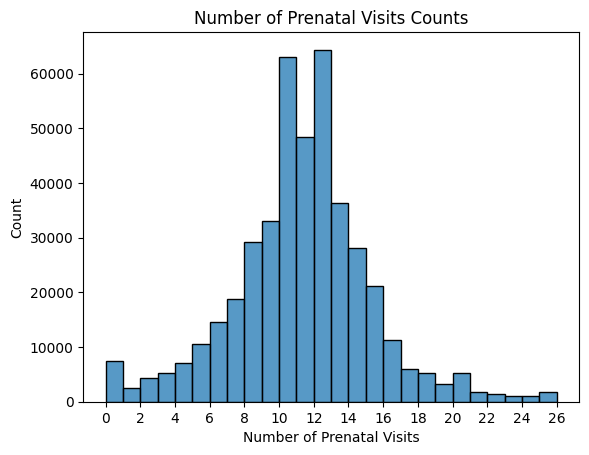

In [18]:
number_of_prenatal_visits_value_counts = df["number_of_prenatal_visits"].value_counts()
number_of_prenatal_visits_value_counts = number_of_prenatal_visits_value_counts.drop(99)

number_of_prenatal_visits_bar_ax = sns.histplot(
    x=number_of_prenatal_visits_value_counts.index,
    weights=number_of_prenatal_visits_value_counts.values,
    bins=range(0, 27, 1),
)
number_of_prenatal_visits_bar_ax.set_title("Number of Prenatal Visits Counts")
number_of_prenatal_visits_bar_ax.set_xlabel("Number of Prenatal Visits")
number_of_prenatal_visits_bar_ax.set_xticks(ticks=range(0, 27, 2))
number_of_prenatal_visits_bar_ax.set_ylabel("Count")
plt.show()

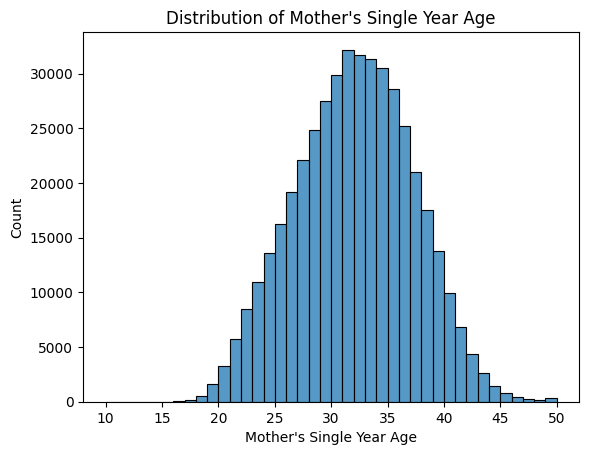

In [19]:
mothers_single_year_age_value_counts = df["mothers_single_year_age"].value_counts()

mothers_single_year_age_bar_ax = sns.histplot(
    x=mothers_single_year_age_value_counts.index,
    weights=mothers_single_year_age_value_counts.values,
    bins=range(10, 51, 1),
)
mothers_single_year_age_bar_ax.set_title("Distribution of Mother's Single Year Age")
mothers_single_year_age_bar_ax.set_xlabel("Mother's Single Year Age")
mothers_single_year_age_bar_ax.set_xticks(ticks=range(10, 51, 5))
mothers_single_year_age_bar_ax.set_ylabel("Count")
plt.show()

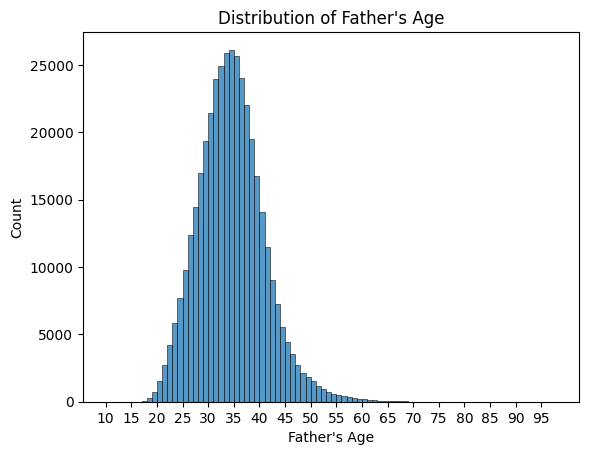

In [20]:
fathers_combined_age_value_counts = df["fathers_combined_age"].value_counts()
fathers_combined_age_value_counts = fathers_combined_age_value_counts.drop(99)

fathers_combined_age_bar_ax = sns.histplot(
    x=fathers_combined_age_value_counts.index,
    weights=fathers_combined_age_value_counts.values,
    bins=range(10, 99, 1),
)
fathers_combined_age_bar_ax.set_title("Distribution of Father's Age")
fathers_combined_age_bar_ax.set_xlabel("Father's Age")
fathers_combined_age_bar_ax.set_xticks(ticks=range(10, 100, 5))
fathers_combined_age_bar_ax.set_ylabel("Count")
plt.show()

### 3. Bivariate Visualizations

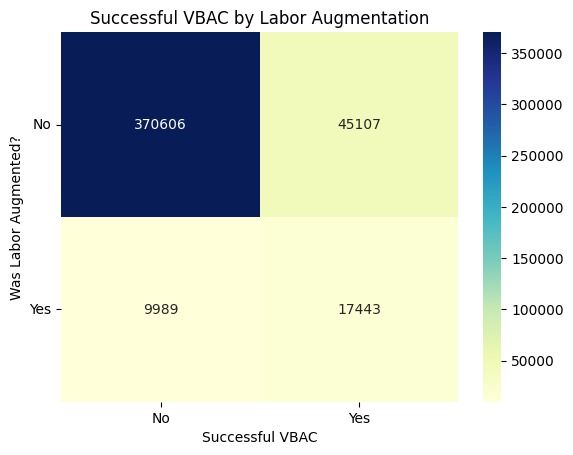

In [21]:
augmentation_of_labor_cross_tab = pd.crosstab(
    df["augmentation_of_labor"], successful_vbac
)

augmentation_of_labor_cross_tab_ax = sns.heatmap(
    augmentation_of_labor_cross_tab, annot=True, fmt="d", cmap="YlGnBu"
)
augmentation_of_labor_cross_tab_ax.set_title("Successful VBAC by Labor Augmentation")
augmentation_of_labor_cross_tab_ax.set_xlabel("Successful VBAC")
augmentation_of_labor_cross_tab_ax.set_xticklabels(["No", "Yes"])
augmentation_of_labor_cross_tab_ax.set_ylabel("Was Labor Augmented?")
augmentation_of_labor_cross_tab_ax.set_yticklabels(["No", "Yes"], rotation=0)
plt.show()

Insights: Labor is not augmented in most cases; however, when it is augmented, it results in 58% more sucessful VBACs.

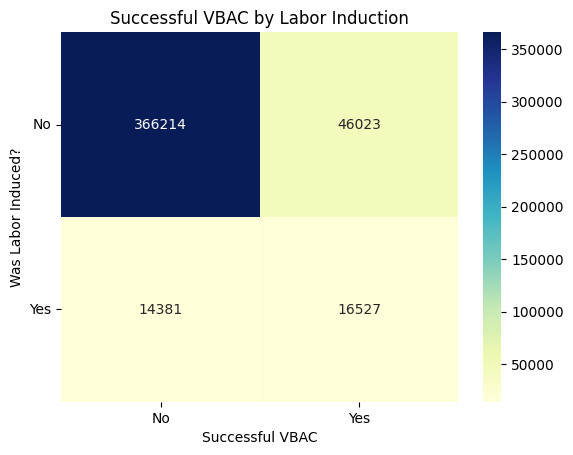

In [22]:
induction_of_labor_cross_tab = pd.crosstab(df["induction_of_labor"], successful_vbac)

induction_of_labor_cross_tab_ax = sns.heatmap(
    induction_of_labor_cross_tab, annot=True, fmt="d", cmap="YlGnBu"
)
induction_of_labor_cross_tab_ax.set_title("Successful VBAC by Labor Induction")
induction_of_labor_cross_tab_ax.set_xlabel("Successful VBAC")
induction_of_labor_cross_tab_ax.set_xticklabels(["No", "Yes"])
induction_of_labor_cross_tab_ax.set_ylabel("Was Labor Induced?")
induction_of_labor_cross_tab_ax.set_yticklabels(["No", "Yes"], rotation=0)
plt.show()

Insights: When labor is induced, it results in about a 50/50 chance of a successful VBAC.

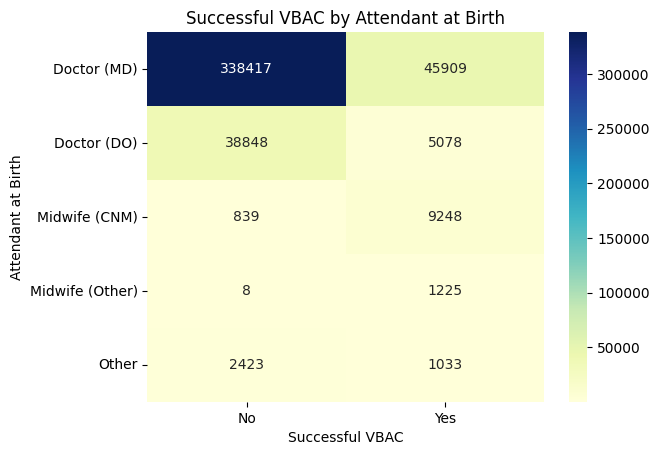

In [24]:
attendant_at_birth_cross_tab = pd.crosstab(df["attendant_at_birth"], successful_vbac)
attendant_at_birth_cross_tab = attendant_at_birth_cross_tab.drop(9)

attendant_at_birth_cross_tab_ax = sns.heatmap(
    attendant_at_birth_cross_tab, annot=True, fmt="d", cmap="YlGnBu"
)
attendant_at_birth_cross_tab_ax.set_title("Successful VBAC by Attendant at Birth")
attendant_at_birth_cross_tab_ax.set_xlabel("Successful VBAC")
attendant_at_birth_cross_tab_ax.set_xticklabels(["No", "Yes"])
attendant_at_birth_cross_tab_ax.set_ylabel("Attendant at Birth")
attendant_at_birth_cross_tab_ax.set_yticklabels(
    [
        "Doctor (MD)",
        "Doctor (DO)",
        "Midwife (CNM)",
        "Midwife (Other)",
        "Other",
    ],
    rotation=0,
)
plt.show()

Insights: When a midwife is the birth attendant, the expectant mother is more likely to have a successful VBAC. However, it's important to note that midwives are unable to perform c-sections, so it may be the case that the birthing mother may attempt a vaginal delivery for longer than she might under the supervision of an attendant who can perform surgery.

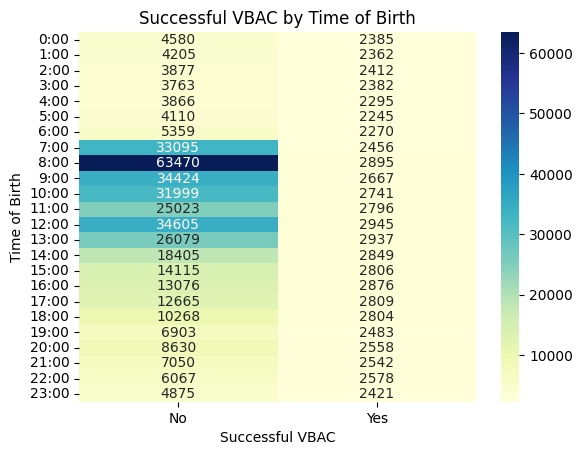

In [ ]:
time_of_birth_bins = pd.cut(
    df["time_of_birth"], bins=range(0, 2401, 100), labels=[f"{i}:00" for i in range(24)]
)
time_of_birth_cross_tab = pd.crosstab(time_of_birth_bins, successful_vbac)

time_of_birth_cross_tab_ax = sns.heatmap(
    time_of_birth_cross_tab, annot=True, fmt="d", cmap="YlGnBu"
)
time_of_birth_cross_tab_ax.set_title("Successful VBAC by Time of Birth")
time_of_birth_cross_tab_ax.set_xlabel("Successful VBAC")
time_of_birth_cross_tab_ax.set_xticklabels(["No", "Yes"])
time_of_birth_cross_tab_ax.set_ylabel("Time of Birth")
time_of_birth_cross_tab_ax.set_yticklabels(time_of_birth_cross_tab.index, rotation=0)
plt.show()

Insights: There is no particular time of day that is more likely to result in a successful VBAC. However, a c-section is more likely to occur during business hours. This is likely the result of pre-scheduled c-sections.

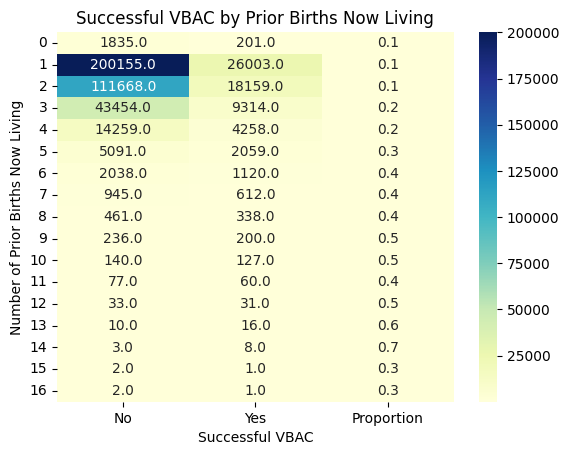

In [ ]:
prior_births_now_living_cross_tab = pd.crosstab(
    df["prior_births_now_living"], successful_vbac
)
prior_births_now_living_cross_tab = prior_births_now_living_cross_tab.drop(99)
prior_births_now_living_cross_tab["proportion"] = prior_births_now_living_cross_tab[
    1
] / (prior_births_now_living_cross_tab[0] + prior_births_now_living_cross_tab[1])

prior_births_now_living_cross_tab_ax = sns.heatmap(
    prior_births_now_living_cross_tab, annot=True, fmt="0.1f", cmap="YlGnBu"
)
prior_births_now_living_cross_tab_ax.set_title(
    "Successful VBAC by Prior Births Now Living"
)
prior_births_now_living_cross_tab_ax.set_xlabel("Successful VBAC")
prior_births_now_living_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
prior_births_now_living_cross_tab_ax.set_ylabel("Number of Prior Births Now Living")
prior_births_now_living_cross_tab_ax.set_yticklabels(
    prior_births_now_living_cross_tab.index, rotation=0
)
plt.show()

Insights: The more children a mother has borne, the more likely she is to have a successful VBAC. This is counterintuitive, but our suspicion is that this may be better explored in the multivariate visualizations in conjunction with number of previous c-sections.

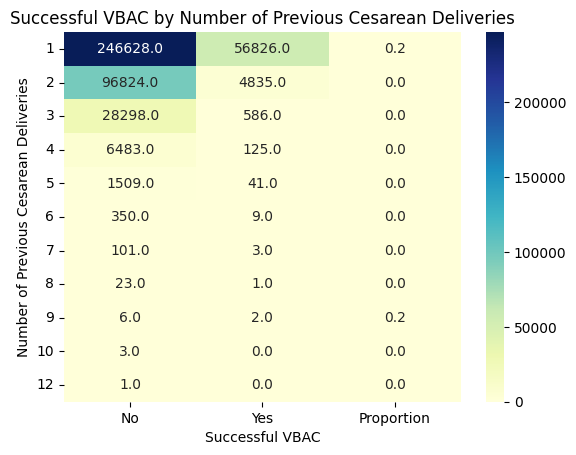

In [ ]:
number_of_previous_cesarean_cross_tab = pd.crosstab(
    df["number_of_previous_cesarean"], successful_vbac
)
number_of_previous_cesarean_cross_tab = number_of_previous_cesarean_cross_tab.drop(99)
number_of_previous_cesarean_cross_tab[
    "proportion"
] = number_of_previous_cesarean_cross_tab[1] / (
    number_of_previous_cesarean_cross_tab[0] + number_of_previous_cesarean_cross_tab[1]
)

number_of_previous_cesarean_cross_tab_ax = sns.heatmap(
    number_of_previous_cesarean_cross_tab, annot=True, fmt="0.1f", cmap="YlGnBu"
)
number_of_previous_cesarean_cross_tab_ax.set_title(
    "Successful VBAC by Number of Previous Cesarean Deliveries"
)
number_of_previous_cesarean_cross_tab_ax.set_xlabel("Successful VBAC")
number_of_previous_cesarean_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
number_of_previous_cesarean_cross_tab_ax.set_ylabel(
    "Number of Previous Cesarean Deliveries"
)
number_of_previous_cesarean_cross_tab_ax.set_yticklabels(
    number_of_previous_cesarean_cross_tab.index, rotation=0
)
plt.show()

Insights: The more c-sections a mother has had, the less likely she is to have a successful VBAC.

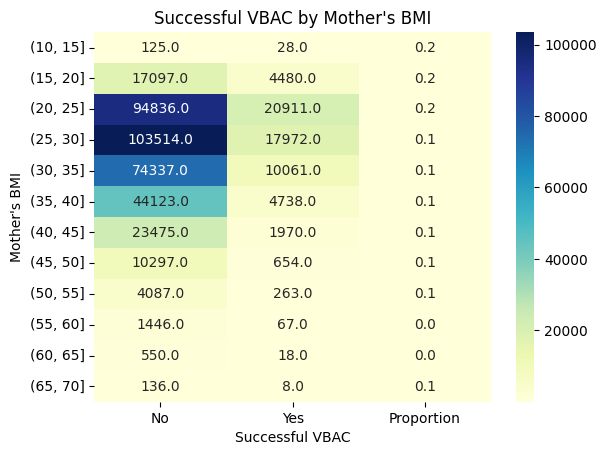

In [45]:
BMI_cross_tab = pd.crosstab(pd.cut(df["BMI"], bins=range(0, 100, 5)), successful_vbac)
BMI_cross_tab["proportion"] = BMI_cross_tab[1] / (BMI_cross_tab[0] + BMI_cross_tab[1])

BMI_cross_tab_ax = sns.heatmap(BMI_cross_tab, annot=True, fmt="0.1f", cmap="YlGnBu")
BMI_cross_tab_ax.set_title("Successful VBAC by Mother's BMI")
BMI_cross_tab_ax.set_xlabel("Successful VBAC")
BMI_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
BMI_cross_tab_ax.set_ylabel("Mother's BMI")
BMI_cross_tab_ax.set_yticklabels(BMI_cross_tab.index.astype(str), rotation=0)
plt.show()

Insights: The number of successful VBACs appears to largely be proportional to the number of c-sections, with a slightly greater chance of success at the lower end of BMI values. However, the highest recorded BMI (65-70) has a very small sample size, so we may discount it for that reason.

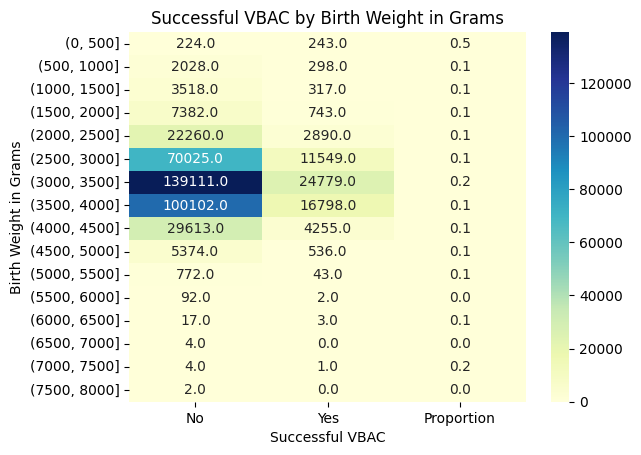

In [ ]:
birth_weight_in_grams_cross_tab = pd.crosstab(
    pd.cut(df["birth_weight_in_grams"], bins=range(0, 8001, 500)), successful_vbac
)
birth_weight_in_grams_cross_tab["proportion_successful_vbac"] = (
    birth_weight_in_grams_cross_tab[1]
    / (birth_weight_in_grams_cross_tab[0] + birth_weight_in_grams_cross_tab[1])
)

birth_weight_in_grams_cross_tab_ax = sns.heatmap(
    birth_weight_in_grams_cross_tab, annot=True, fmt="0.1f", cmap="YlGnBu"
)
birth_weight_in_grams_cross_tab_ax.set_title("Successful VBAC by Birth Weight in Grams")
birth_weight_in_grams_cross_tab_ax.set_xlabel("Successful VBAC")
birth_weight_in_grams_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
birth_weight_in_grams_cross_tab_ax.set_ylabel("Birth Weight in Grams")
birth_weight_in_grams_cross_tab_ax.set_yticklabels(
    birth_weight_in_grams_cross_tab.index.astype(str), rotation=0
)
plt.show()

Insights: The number of successful VBACs at different birth weights appears to be similarly proportional to the number of c-sections.

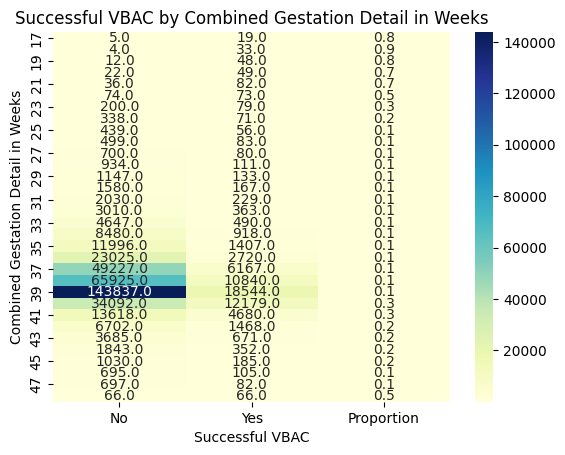

In [ ]:
combined_gestation_detail_cross_tab = pd.crosstab(
    df["combined_gestation_detail_in_weeks"],
    successful_vbac,
)
combined_gestation_detail_cross_tab["proportion"] = combined_gestation_detail_cross_tab[
    1
] / (combined_gestation_detail_cross_tab[0] + combined_gestation_detail_cross_tab[1])

combined_gestation_detail_cross_tab_ax = sns.heatmap(
    combined_gestation_detail_cross_tab, annot=True, fmt="0.1f", cmap="YlGnBu"
)
combined_gestation_detail_cross_tab_ax.set_title(
    "Successful VBAC by Combined Gestation Detail in Weeks"
)
combined_gestation_detail_cross_tab_ax.set_xlabel("Successful VBAC")
combined_gestation_detail_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
combined_gestation_detail_cross_tab_ax.set_ylabel("Combined Gestation Detail in Weeks")
plt.show()

Insights: Preterm deliveries are most likely to result in a VBAC; however, we would not consider these to be "successful", as deliveries prior to 28 weeks gestation have a near-100% chance of mortality.

Of term or near-term deliveries, those at 40-41 weeks are most likely to have successful VBACs.

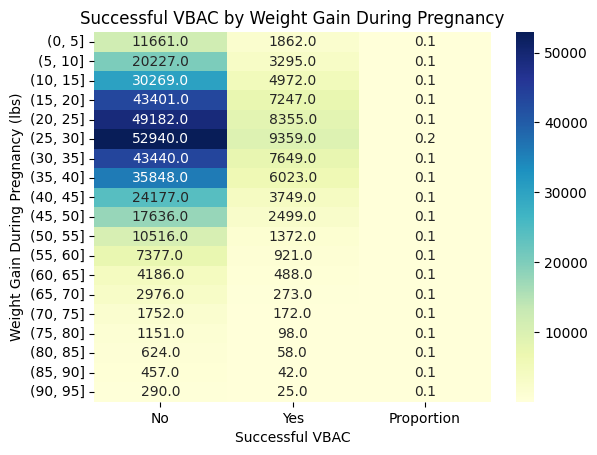

In [ ]:
weight_gain_cross_tab = pd.crosstab(
    pd.cut(df["weight_gain"], bins=range(0, 100, 5)), successful_vbac
)
weight_gain_cross_tab["proportion"] = weight_gain_cross_tab[1] / (
    weight_gain_cross_tab[0] + weight_gain_cross_tab[1]
)

weight_gain_cross_tab_ax = sns.heatmap(
    weight_gain_cross_tab, annot=True, fmt="0.1f", cmap="YlGnBu"
)
weight_gain_cross_tab_ax.set_title("Successful VBAC by Weight Gain During Pregnancy")
weight_gain_cross_tab_ax.set_xlabel("Successful VBAC")
weight_gain_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
weight_gain_cross_tab_ax.set_ylabel("Weight Gain During Pregnancy (lbs)")
weight_gain_cross_tab_ax.set_yticklabels(
    weight_gain_cross_tab.index.astype(str), rotation=0
)
plt.show()

Insights: The number of successful VBACs for different pregnancy weight gains is approximately proportional to the number of c-sections.

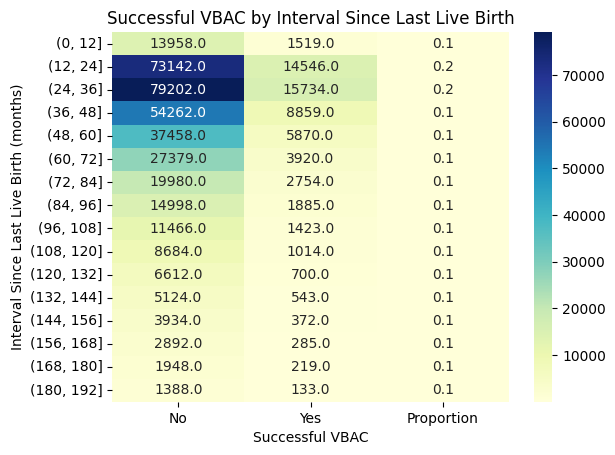

In [ ]:
interval_since_last_live_birth_cross_tab = pd.crosstab(
    pd.cut(df["interval_since_last_live_birth"], bins=range(0, 201, 12)),
    successful_vbac,
)
interval_since_last_live_birth_cross_tab[
    "proportion"
] = interval_since_last_live_birth_cross_tab[1] / (
    interval_since_last_live_birth_cross_tab[0]
    + interval_since_last_live_birth_cross_tab[1]
)

interval_since_last_live_birth_cross_tab_ax = sns.heatmap(
    interval_since_last_live_birth_cross_tab, annot=True, fmt="0.1f", cmap="YlGnBu"
)
interval_since_last_live_birth_cross_tab_ax.set_title(
    "Successful VBAC by Interval Since Last Live Birth"
)
interval_since_last_live_birth_cross_tab_ax.set_xlabel("Successful VBAC")
interval_since_last_live_birth_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
interval_since_last_live_birth_cross_tab_ax.set_ylabel(
    "Interval Since Last Live Birth (months)"
)
interval_since_last_live_birth_cross_tab_ax.set_yticklabels(
    interval_since_last_live_birth_cross_tab.index.astype(str), rotation=0
)
plt.show()

Insights: Those who wait between 12-36 months to bear another child are more likely to have a successful VBAC.

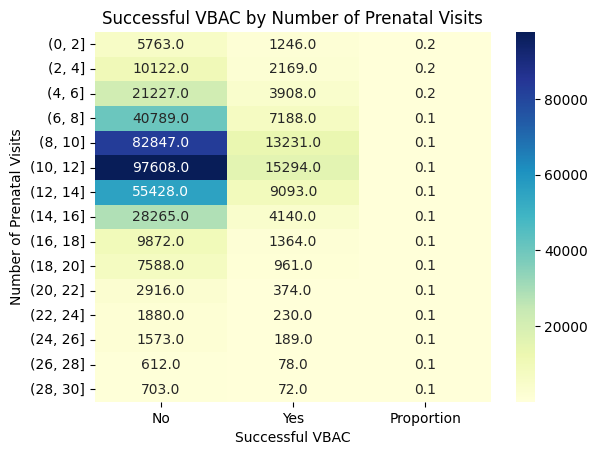

In [ ]:
number_of_prenatal_visits_cross_tab = pd.crosstab(
    pd.cut(df["number_of_prenatal_visits"], bins=range(0, 31, 2)),
    successful_vbac,
)
number_of_prenatal_visits_cross_tab["proportion"] = number_of_prenatal_visits_cross_tab[
    1
] / (number_of_prenatal_visits_cross_tab[0] + number_of_prenatal_visits_cross_tab[1])

number_of_prenatal_visits_cross_tab_ax = sns.heatmap(
    number_of_prenatal_visits_cross_tab, annot=True, fmt="0.1f", cmap="YlGnBu"
)
number_of_prenatal_visits_cross_tab_ax.set_title(
    "Successful VBAC by Number of Prenatal Visits"
)
number_of_prenatal_visits_cross_tab_ax.set_xlabel("Successful VBAC")
number_of_prenatal_visits_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
number_of_prenatal_visits_cross_tab_ax.set_ylabel("Number of Prenatal Visits")
plt.show()

Insights: Fewer prenatal visits appear to result in greater chances of VBACs. However, this is likely due to low medical provider involvement, and it would likely be preferable for those mothers to have received more prenatal care. It would be interesting to know how well these mothers recovered after vaginal birth, and if a c-section would have been preferable for medical reasons.

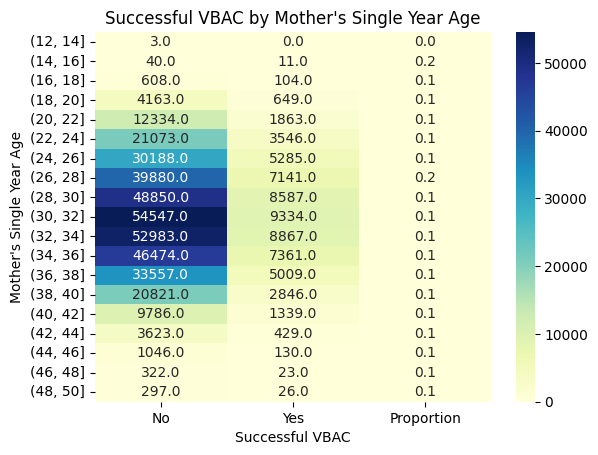

In [ ]:
mothers_single_year_age_cross_tab = pd.crosstab(
    pd.cut(df["mothers_single_year_age"], bins=range(10, 51, 2)),
    successful_vbac,
)
mothers_single_year_age_cross_tab["proportion"] = mothers_single_year_age_cross_tab[
    1
] / (mothers_single_year_age_cross_tab[0] + mothers_single_year_age_cross_tab[1])

mothers_single_year_age_cross_tab_ax = sns.heatmap(
    mothers_single_year_age_cross_tab, annot=True, fmt="0.1f", cmap="YlGnBu"
)
mothers_single_year_age_cross_tab_ax.set_title(
    "Successful VBAC by Mother's Single Year Age"
)
mothers_single_year_age_cross_tab_ax.set_xlabel("Successful VBAC")
mothers_single_year_age_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
mothers_single_year_age_cross_tab_ax.set_ylabel("Mother's Single Year Age")
mothers_single_year_age_cross_tab_ax.set_yticklabels(
    mothers_single_year_age_cross_tab.index.astype(str), rotation=0
)
plt.show()

Insights: Largely, age appears to have little or no bearing on VBAC success.

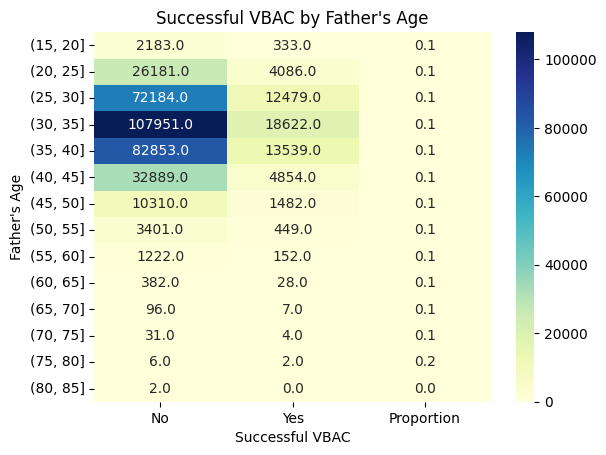

In [ ]:
fathers_combined_age_cross_tab = pd.crosstab(
    pd.cut(df["fathers_combined_age"], bins=range(10, 100, 5)),
    successful_vbac,
)
fathers_combined_age_cross_tab["proportion"] = fathers_combined_age_cross_tab[1] / (
    fathers_combined_age_cross_tab[0] + fathers_combined_age_cross_tab[1]
)

fathers_combined_age_cross_tab_ax = sns.heatmap(
    fathers_combined_age_cross_tab, annot=True, fmt="0.1f", cmap="YlGnBu"
)
fathers_combined_age_cross_tab_ax.set_title("Successful VBAC by Father's Age")
fathers_combined_age_cross_tab_ax.set_xlabel("Successful VBAC")
fathers_combined_age_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
fathers_combined_age_cross_tab_ax.set_ylabel("Father's Age")
fathers_combined_age_cross_tab_ax.set_yticklabels(
    fathers_combined_age_cross_tab.index.astype(str), rotation=0
)
plt.show()

Insights: Similarly, the father's age has little to no bearing on a successful VBAC.

### 4. Multivariate Visualizations

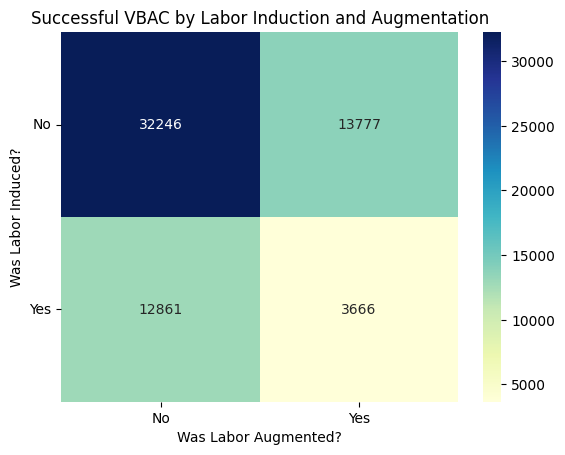

In [ ]:
induction_augmentation_cross_tab = pd.crosstab(
    df["induction_of_labor"],
    df["augmentation_of_labor"],
    values=successful_vbac,
    aggfunc="sum",
)

induction_augmentation_cross_tab_ax = sns.heatmap(
    induction_augmentation_cross_tab, annot=True, fmt="d", cmap="YlGnBu"
)
induction_augmentation_cross_tab_ax.set_title(
    "Successful VBAC by Labor Induction and Augmentation"
)
induction_augmentation_cross_tab_ax.set_xlabel("Was Labor Augmented?")
induction_augmentation_cross_tab_ax.set_xticklabels(["No", "Yes"])
induction_augmentation_cross_tab_ax.set_ylabel("Was Labor Induced?")
induction_augmentation_cross_tab_ax.set_yticklabels(["No", "Yes"], rotation=0)
plt.show()

Of our successful VBACs, the majority occurred naturally (as in, without induction or augmentation). About 3,600 occurred using both augmentation and induction. About 27,000 occurred with one or the other. We can conclude that both inducing and augmenting labor does not necessarily produce better results. This likely is because a birth attendant is unlikely to augment labor in a mother who has had a previous c-section, and instead opts for a repeat c-section.

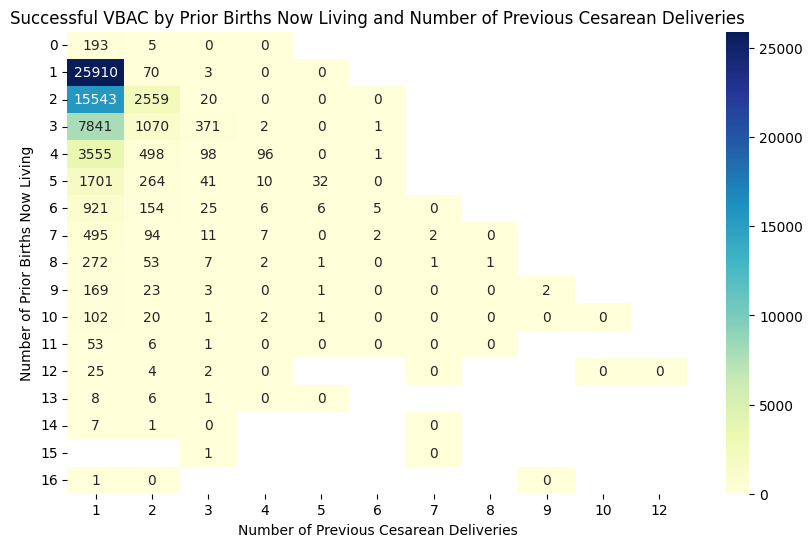

In [ ]:
prior_births_previous_cesarean_cross_tab = pd.crosstab(
    df["prior_births_now_living"],
    df["number_of_previous_cesarean"],
    values=successful_vbac,
    aggfunc="sum",
)
prior_births_previous_cesarean_cross_tab = (
    prior_births_previous_cesarean_cross_tab.drop(99, axis=0).drop(99, axis=1)
)

plt.figure(figsize=(10, 6))
prior_births_previous_cesarean_cross_tab_ax = sns.heatmap(
    prior_births_previous_cesarean_cross_tab, annot=True, fmt=".0f", cmap="YlGnBu"
)
prior_births_previous_cesarean_cross_tab_ax.set_title(
    "Successful VBAC by Prior Births Now Living and Number of Previous Cesarean Deliveries"
)
prior_births_previous_cesarean_cross_tab_ax.set_xlabel(
    "Number of Previous Cesarean Deliveries"
)
prior_births_previous_cesarean_cross_tab_ax.set_xticklabels(
    prior_births_previous_cesarean_cross_tab.columns, rotation=0
)
prior_births_previous_cesarean_cross_tab_ax.set_ylabel(
    "Number of Prior Births Now Living"
)
prior_births_previous_cesarean_cross_tab_ax.set_yticklabels(
    prior_births_previous_cesarean_cross_tab.index, rotation=0
)
plt.show()

Insights: A successful VBAC is most likely to occur after 1 previous c-section. The more prior births and c-sections that have occurred, the less likely a successful VBAC becomes.